In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap

# Load data
df = pd.read_csv("../data/raw/insurance_data.csv")

print("Environment configured and dependencies ready.")

Environment configured and dependencies ready.


In [5]:
# 1. Feature Engineering: Extract basic operational metrics
if 'RegistrationYear' in df.columns:
    df['VehicleAge'] = 2026 - df['RegistrationYear']
else:
    df['VehicleAge'] = 5  # Fallback median

# 2. Filter for Severity Modeling (only records with claims)
severity_df = df[df['TotalClaims'] > 0].copy()

# 🎯 FIXED HERE: Your data uses 'SumInsured' for asset valuation
real_value_col = 'SumInsured'

# Select explicit features from your real columns list
features = ['VehicleAge', 'Gender', 'Province', real_value_col]

# Clean up missing data dynamically
severity_df = severity_df.dropna(subset=features + ['TotalClaims'])

X = severity_df[features]
y = severity_df['TotalClaims']

# One-Hot Encode Categorical values
X_encoded = pd.get_dummies(X, columns=['Gender', 'Province'], drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Success! Data preprocessed smoothly with 'SumInsured'.")
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Success! Data preprocessed smoothly with 'SumInsured'.
Training shape: (1483, 11), Testing shape: (371, 11)


In [6]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
}

results = {}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "R2": r2}

# Display Performance Summary Table
performance_df = pd.DataFrame(results).T
performance_df

,RMSE,R2
Linear Regression,19249.087248,0.236202
Random Forest,21424.967676,0.053766
XGBoost,20769.837647,0.110749


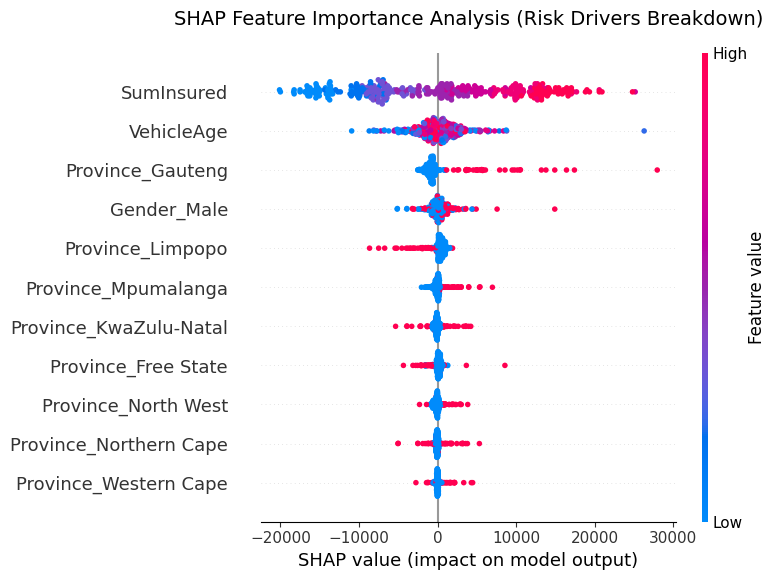

In [9]:
# 1. Select your best performing model
best_model = models["XGBoost"]

# 🎯 THE FIX: Force entire training/testing datasets to float64 so SHAP can compute it
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# 2. Initialize SHAP TreeExplainer with numeric data
# Using TreeExplainer directly handles XGBoost much more efficiently
explainer = shap.TreeExplainer(best_model, X_train_numeric)
shap_values = explainer(X_test_numeric)

# 3. Plot Feature Importance Summary
plt.figure(figsize=(10, 6))
# Remove the inner title parameter from show=False to avoid text overlapping
shap.summary_plot(shap_values, X_test_numeric, show=False)
plt.title("SHAP Feature Importance Analysis (Risk Drivers Breakdown)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()